In [2]:
import numpy as np

In [15]:
!pip install pymcel
import pymcel as pc

In [1]:
%pip install -Uq rebound

Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for rebound (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [59 lines of output]
      fatal: not a git repository (or any of the parent directories): .git
      <string>:91: DeprecationWarning: codecs.open() is deprecated. Use open() instead.
      C:\Users\Lizeth\AppData\Local\Temp\pip-build-env-hlrna6tt\overlay\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'tests_require'
        warnings.warn(msg)
      C:\Users\Lizeth\AppData\Local\Temp\pip-build-env-hlrna6tt\overlay\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      C:\Users\Lizeth\AppData\Local\Temp\pip-build-env-hlrna6tt\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ***************************************************

In [3]:
conda install -c conda-forge rebound

3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: failed

Note: you may need to restart the kernel to use updated packages.



PackagesNotFoundError: The following packages are not available from current channels:

  - rebound

Current channels:

  - https://conda.anaconda.org/conda-forge
  - defaults

To search for alternate channels that may provide the conda package you're
looking for, navigate to

    https://anaconda.org

and use the search bar at the top of the page.




In [13]:
%pip install pandas plotly nbformat

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from datetime import datetime

# Obtener la fecha actual
fecha_actual = datetime.now()

# Obtener posición y velocidad del Sol
posicion_sol = pc.sun_position(fecha_actual)
velocidad_sol = pc.sun_velocity(fecha_actual)

print(f"Fecha: {fecha_actual}")
print(f"Posición del Sol: {posicion_sol}")
print(f"Velocidad del Sol: {velocidad_sol}")

AttributeError: module 'pymcel' has no attribute 'sun_position'

In [8]:
tabla, jd, X_sol = pc.consulta_horizons(
    id = 'Sun',
    location='@SSB',
    epochs='2026-02-26 00:00:00'
)

X_sol

AttributeError: module 'pymcel' has no attribute 'consulta_horizons'

In [9]:
tabla, jd, X_jup = pc.consulta_horizons(
    id = 'Jupiter Barycenter',
    location='@SSB',
    epochs='2026-02-26 00:00:00'
)

X_jup

AttributeError: module 'pymcel' has no attribute 'consulta_horizons'

In [10]:
r_sol_0 = X_sol[:3]
v_sol_0 = X_sol[3:] 

r_jup_0 = X_jup[:3]
v_jup_0 = X_jup[3:]

NameError: name 'X_sol' is not defined

In [11]:
deltat = 1 + 86400
r_jup_dt = r_jup_0 + v_jup_0 * deltat
r_sol_dt = r_sol_0 + v_sol_0 * deltat

r_jup_0, r_sol_0

(array([-3.13499559e+11,  7.16531655e+11,  4.04379637e+09]),
 array([-3.99267884e+08, -8.24090450e+08,  1.85429947e+07]))

In [16]:
mu_sol = pc.constantes.mu_sun
mu_jup = pc.constantes.mu_jupiter
rij_vec = r_jup_0 - r_sol_0
v_jup_dt = v_jup_0 - mu_sol * rij_vec / np.linalg.norm(rij_vec)**3 * deltat
v_jup_dt

array([-12117.89031917,  -4635.79226784,    290.41467397])

In [15]:
rij_vec_sol = r_sol_0 - r_jup_0
v_sol_dt = v_sol_0 - mu_jup * rij_vec_sol / np.linalg.norm(rij_vec_sol)**3 * deltat

v_sol_dt

array([12.20367452,  1.25570491, -0.24251222])

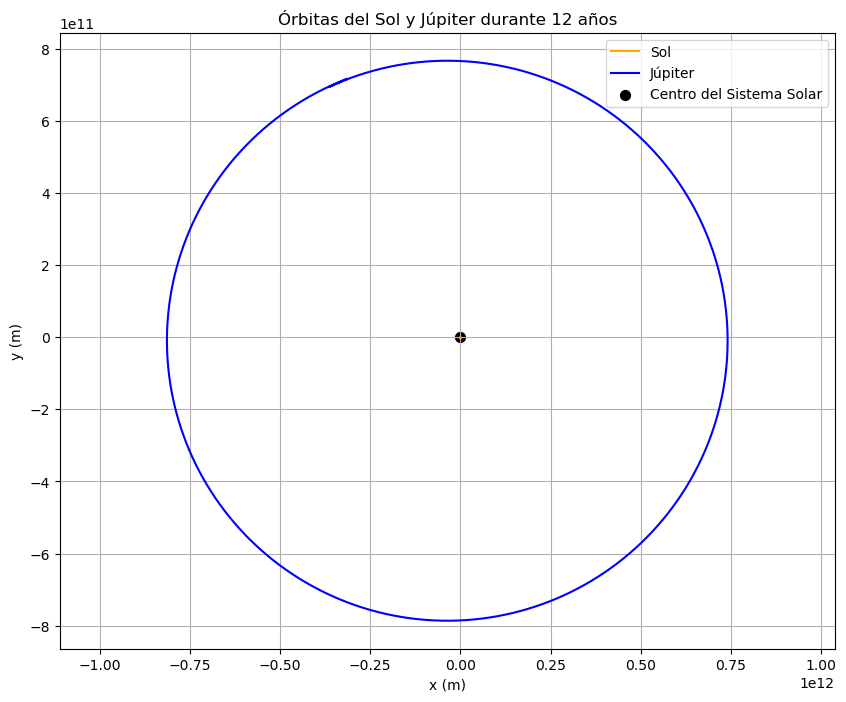

In [17]:
import matplotlib.pyplot as plt

# Configuración inicial
num_dias = 12 * 365  # 12 años en días
dt = 86400  # Un día en segundos

# Listas para almacenar las posiciones
posiciones_sol = [r_sol_0]
posiciones_jup = [r_jup_0]

# Iterar para calcular las posiciones
r_sol = r_sol_0
v_sol = v_sol_0
r_jup = r_jup_0
v_jup = v_jup_0

for _ in range(num_dias):
    rij_vec = r_jup - r_sol
    rij_vec_sol = r_sol - r_jup

    # Actualizar velocidades
    v_jup += -mu_sol * rij_vec / np.linalg.norm(rij_vec)**3 * dt
    v_sol += -mu_jup * rij_vec_sol / np.linalg.norm(rij_vec_sol)**3 * dt

    # Actualizar posiciones
    r_jup += v_jup * dt
    r_sol += v_sol * dt

    # Almacenar posiciones
    posiciones_sol.append(r_sol.copy())
    posiciones_jup.append(r_jup.copy())

# Convertir listas a arrays para graficar
posiciones_sol = np.array(posiciones_sol)
posiciones_jup = np.array(posiciones_jup)

# Graficar las órbitas
plt.figure(figsize=(10, 8))
plt.plot(posiciones_sol[:, 0], posiciones_sol[:, 1], label="Sol", color="orange")
plt.plot(posiciones_jup[:, 0], posiciones_jup[:, 1], label="Júpiter", color="blue")
plt.scatter(0, 0, color="black", label="Centro del Sistema Solar", s=50)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Órbitas del Sol y Júpiter durante 12 años")
plt.legend()
plt.axis("equal")
plt.grid()
plt.show()

In [ ]:
# Calcular la energía cinética y potencial en cada instante
energia_cinetica = []
energia_potencial = []
energia_total = []

for i in range(len(posiciones_sol)):
    # Posiciones y velocidades actuales
    r_sol = posiciones_sol[i]
    r_jup = posiciones_jup[i]
    v_sol = np.linalg.norm(v_sol_0)  # Velocidad constante del Sol
    v_jup = np.linalg.norm(v_jup_0)  # Velocidad constante de Júpiter

    # Energía cinética
    ec_sol = 0.5 * mu_sol * v_sol**2
    ec_jup = 0.5 * mu_jup * v_jup**2
    energia_cinetica.append(ec_sol + ec_jup)

    # Energía potencial
    distancia = np.linalg.norm(r_jup - r_sol)
    ep = -mu_sol * mu_jup / distancia
    energia_potencial.append(ep)

    # Energía total
    energia_total.append(ec_sol + ec_jup + ep)

# Crear el gráfico
tiempo = np.arange(0, len(energia_total)) * dt / 86400  # Tiempo en días

plt.figure(figsize=(10, 6))
plt.plot(tiempo, energia_total, label="Energía Total", color="green")
plt.xlabel("Tiempo (días)")
plt.ylabel("Energía Total (J)")
plt.title("Energía Total del Sistema como Función del Tiempo")
plt.grid()
plt.legend()
plt.show()